<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png" width="250" style="display: block; margin-left: auto; margin-right: auto;">

# Premier League – Data Preparation and Feature Engineering

## Purpose

This notebook turns the main EDA findings into one clear and reproducible preprocessing workflow. The priority is to understand **what each step does and why it is necessary**.

By the end, we will be able to:

- validate the minimum input-data contract;
- create the temporal train / test partition without fitting transformations beforehand;
- create a small set of features justified by the EDA;
- impute, encode, and scale different types of variables;
- assemble all transformations into a scikit-learn pipeline;
- prepare the handoff to model comparison without consulting the test set.

```text
Raw data
    ↓
Anomaly correction + validation
    ↓
Temporal train / test
    ↓
Feature engineering
    ↓
Imputation + encoding + scaling
    ↓
Model
```

## 1. Imports and project paths

Dependencies should be installed from the project environment, not from a `pip install` cell inside the notebook.

In [1]:
from __future__ import annotations

import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Declared for the modeling notebook, which uses it for cross-validation
# shuffling and for estimators that subsample. Under an explicit date cut
# this notebook never samples, so the value has no effect here.
RANDOM_STATE = 42
TARGET_COLUMN = "FTR"
CUTOFF = pd.Timestamp("2025-08-01")
# Sliding Window Size
K = 5

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data" / "processed").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT / "data" / "processed"
    / "premier_league_2021_2026.csv"
)

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.14.6
pandas: 3.0.5
scikit-learn: 1.9.1


In [2]:
REQUIRED_COLUMNS = [
    "Season",
    "Date",
    "Time",
    "HomeTeam",
    "AwayTeam",
    "FTR",
    "FTHG",
    "FTAG",
    "AvgH",
    "AvgD",
    "AvgA",
    "AHh",
]

# The 17 columns that only exist after the final whistle. FTHG and FTAG are
# the deliberate exception: they enter as the results of *earlier* matches.
POST_MATCH_COLUMNS = [
    "FTHG",
    "FTAG",
    "HTHG",
    "HTAG",
    "HTR",
    "HS",
    "AS",
    "HST",
    "AST",
    "HF",
    "AF",
    "HC",
    "AC",
    "HY",
    "AY",
    "HR",
    "AR",
]

# The 42 exchange 1X2 quote columns. This is the only block of the dataset
# where absence is structural, so it is the only place where an availability
# indicator has non-zero variance.
ODDS_QUOTE_COLS = [
    "BFH", "BFD", "BFA", "1XBH", "1XBD", "1XBA",
    "BFEH", "BFED", "BFEA", "BFDH", "BFDD", "BFDA",
    "BFCH", "BFCD", "BFCA", "1XBCH", "1XBCD", "1XBCA",
    "BFDCH", "BFDCD", "BFDCA",
    "BFECH", "BFECD", "BFECA",
    "BMGMH", "BMGMD", "BMGMA", "BMGMCH", "BMGMCD", "BMGMCA",
    "CLH", "CLD", "CLA", "CLCH", "CLCD", "CLCA",
    "LBH", "LBD", "LBA", "LBCH", "LBCD", "LBCA",
]

# Positive whitelist. Subtracting a list is as fragile as adding one.
ALLOWED_RAW_COLUMNS = (
    ["Season", "Date", "Time", "HomeTeam", "AwayTeam",
     "FTHG", "FTAG",
     "AvgH", "AvgD", "AvgA", "AHh"]
    + ODDS_QUOTE_COLS
)

# The features that survive the redundancy pruning of the catalogue.
HIST_KEEP = [
    "Home_Hist_Pts_k",
    "Away_Hist_Pts_k",
    "Diff_Hist_Pts_k",
    "Home_Hist_GF_k",
    "Away_Hist_GF_k",
    "Diff_Hist_GF_k",
    "Home_Hist_GA_k",
    "Away_Hist_GA_k",
    "Home_Hist_W_k",
    "Away_Hist_W_k",
    "Home_Hist_L_k",
    "Away_Hist_L_k",
]
MARKET_KEEP = ["p_home", "p_draw", "p_away", "Mkt_Gap", "AHh"]
CAL_KEEP = ["Home_MatchesPlayed", "Away_MatchesPlayed", "OddsQuotes"]
DOW_KEEP = ["DayOfWeek"]
BASE_FEATURES = HIST_KEEP + MARKET_KEEP + CAL_KEEP + DOW_KEEP

# Raw identity columns kept so the one-hot block can consume them.
CLUB_COLS = ["HomeTeam", "AwayTeam"]
PIPELINE_FEATURES = BASE_FEATURES + CLUB_COLS


# Verified expectations used by the validation and split assertions.
MATCHES_PER_SEASON = 380
TRAIN_ROWS = 1520
TEST_ROWS = 380
# Corrected total shots for Newcastle - West Ham, 15/08/2021, where
# shots on target exceeded total shots; verified against an external
# source.
CORRECTED_AS = 18

## 2. Load and validate the raw data

The EDA identified the expected columns and valid ranges. We now convert those observations into executable checks. If the input schema changes, the notebook should stop with an informative message instead of silently ignoring the problem.

The raw frame has 157 columns, so `X = df` would hand every one of them to the model. Section 7 replaces that with an explicit whitelist; this section only checks that the frame is sound.

In [3]:
df = pd.read_csv(DATA_PATH)

missing_columns = [
    column for column in REQUIRED_COLUMNS if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not df[TARGET_COLUMN].isin(["H", "D", "A"]).all():
    raise ValueError("FTR must contain only H, D or A.")

if (df["HomeTeam"] == df["AwayTeam"]).any():
    raise ValueError("HomeTeam must differ from AwayTeam.")

primary_key = ["Season", "HomeTeam", "AwayTeam"]

if df.duplicated(subset=primary_key).any():
    raise ValueError(f"{primary_key} must be unique.")

if not df.groupby("Season").size().eq(MATCHES_PER_SEASON).all():
    raise ValueError(
        f"Every season must contain {MATCHES_PER_SEASON} matches."
    )

print(f"Validated dataset: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Validated dataset: 1900 rows and 157 columns

,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,...,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-2022,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Verify impossible ranges and invalid categories

The checks above confirm the schema is present and free of duplicates. This one
confirms the values themselves are physically possible. A decimal bookmaker
quote below 1.00 would be a guaranteed profit, and a negative goal cannot
happen, so both are domain violations rather than outliers to be tolerated.

`AvgH/D/A` and `MaxH/D/A` cover the three 1X2 families (opening, closing and
aggregated): `Avg*` is the market mean, `Max*` the far end of the quoted range.
Checking those six is enough to represent the bookmakers without listing 48
correlated columns.

`FTHG`, `FTAG`, `HTHG` and `HTAG` are checked here but never reach the model.
They belong to `POST_MATCH_COLUMNS`; validating them is a data quality matter,
not an admission to the feature set.

In [4]:
if set(df["Div"].unique()) != {"E0"}:
    raise ValueError(f"Div must be E0, found {set(df['Div'].unique())}")

if not df["Season"].str.match(r"^\d{4}-\d{4}$").all():
    raise ValueError("Season must look like 2021-2022.")

if not df["Time"].str.match(r"^\d{2}:\d{2}$").all():
    raise ValueError("Time must look like 15:00.")

odds_columns = ["AvgH", "AvgD", "AvgA", "MaxH", "MaxD", "MaxA"]

if df[odds_columns].le(1.0).any().any():
    raise ValueError(f"Bookmaker odds must be above 1.0: {odds_columns}")

goal_columns = ["FTHG", "FTAG", "HTHG", "HTAG"]

if df[goal_columns].lt(0).any().any():
    raise ValueError(f"Goals cannot be negative: {goal_columns}")

numeric_block = df.select_dtypes(include="number").to_numpy(dtype=float)

if np.isinf(numeric_block).any():
    raise ValueError("Infinite values in the numeric block.")

nan_cells = int(np.isnan(numeric_block).sum())

print("Impossible ranges and invalid categories: none found.")
print(f"All numeric values finite; {nan_cells} missing cells recorded.")

Impossible ranges and invalid categories: none found.
All numeric values finite; 86394 missing cells recorded.


### Correct one reproducible anomaly

The EDA found exactly one internally inconsistent row: `AST > AS` in Newcastle - West Ham on 15/08/2021. Shots on target cannot exceed total shots. The real value of `AS` is 18, verified against an external source. The match key is asserted to match exactly one row before anything is written.

In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

match_key = (
    (df["Date"] == "2021-08-15")
    & (df["HomeTeam"] == "Newcastle")
    & (df["AwayTeam"] == "West Ham")
)

if int(match_key.sum()) != 1:
    raise ValueError(
        "Expected exactly 1 Newcastle-West Ham row, got "
        f"{int(match_key.sum())}"
    )

df.loc[match_key, "AS"] = CORRECTED_AS

if not df["AST"].le(df["AS"]).all():
    raise ValueError("AST must not exceed AS.")

if not df["HST"].le(df["HS"]).all():
    raise ValueError("HST must not exceed HS.")

print("Anomaly corrected and the shot invariants hold.")

Anomaly corrected and the shot invariants hold.


## 3. Separate the target and create the temporal partitions

We split before fitting imputers, encoders, scalers, or models. The split is a **date cutoff**, not a random sample, because the problem is to predict a season the model has not seen. The home-win rate ranges from 40.79 % to 48.42 % across the five seasons, an amplitude of 7.63% that is wider than the 5% noise threshold of the EDA, so a random split would mix seasons with different profiles and the test set would stop measuring what we care about.

`stratify` is not an option here: replicating the test season's proportions inside the training set would reproduce exactly the distribution the training set must ignore. The drift between the two halves is information, not a defect to correct.

In [6]:
is_test = df["Date"] >= CUTOFF
df_train = df.loc[~is_test].copy()
df_test = df.loc[is_test].copy()

assert len(df_train) + len(df_test) == len(df)
assert set(df_train.index).isdisjoint(df_test.index)
assert df_train["Date"].max() < df_test["Date"].min()
assert df_train["Season"].nunique() == 4
assert df_test["Season"].nunique() == 1
assert (len(df_train), len(df_test)) == (TRAIN_ROWS, TEST_ROWS)
assert df_train["Date"].max() < CUTOFF <= df_test["Date"].min()

def period(frame):
    """Return the first and last match date as a readable string."""
    start = frame["Date"].min()
    end = frame["Date"].max()
    return f"{start:%Y-%m-%d} to {end:%Y-%m-%d}"


print(f"Train rows: {len(df_train)} ({period(df_train)})")
print(f"Test rows: {len(df_test)} ({period(df_test)})")

Train rows: 1520 (2021-08-13 to 2025-05-25)
Test rows: 380 (2025-08-15 to 2026-05-24)


The test season is harder than the training seasons: it has 4.34% more draws and 1.91% fewer home wins. We print the full distribution rather than hiding it, because that difference is the evidence that the temporal cut is meaningful.

In [7]:
season_share = (
    100
    * pd.crosstab(df["Season"], df[TARGET_COLUMN], normalize="index")
    .round(2)
    .add_suffix(" %")
)
season_share

FTR,A %,D %,H %
Season,,,
2021-2022,34.0,23.0,43.0
2022-2023,29.0,23.0,48.0
2023-2024,32.0,22.0,46.0
2024-2025,35.0,24.0,41.0
2025-2026,30.0,27.0,43.0


## 4. Problem, target distribution and reference accuracy

**What is predicted.** `FTR` is a 3-class classification with a closed domain `{H, D, A}`, one row per match. The natural primary key is `(Season, HomeTeam, AwayTeam)`.

The smallest class `draw` consists of 454 observations ( 23.89% approx ), so no class is empty and no minority is negligible. No oversampling or undersampling is applied; the natural distribution is what the model should learn.  


**Prediction instant T-0.** T-0 is the kickoff whistle. At T-0 we know the date, the kickoff time, home and away status, both club identities and every odds quote. We do **not** know the result, the half-time score or any in-match statistic. A feature that carries information from after T-0 would make the model unusable at the moment it is needed, even if it scored well in this notebook.

Closing odds (the `C` columns) *are* available at T-0. They are excluded by redundancy, not by leakage, and we say so rather than inventing a cleaner-sounding excuse.

In [8]:
def market_probabilities(frame, cols=("AvgH", "AvgD", "AvgA")):
    """Return de-vigged 1X2 probabilities, one row per match.

    Applies the proportional de-vig p_i = (1 / o_i) / sum_j (1 / o_j),
    assuming the bookmaker margin splits equally across the outcomes.

    Parameters
    ----------
    frame : pandas.DataFrame
        Match frame with the three 1X2 quote columns.
    cols : tuple of str
        Quote columns, in home, draw, away order.

    Returns
    -------
    numpy.ndarray
        One probability per outcome, shape (len(frame), 3); each row
        sums to 1.
    """
    inverse = 1.0 / frame[list(cols)].to_numpy(dtype=float)
    return inverse / inverse.sum(axis=1, keepdims=True)


classes = np.array(["H", "D", "A"])
target_share = df[TARGET_COLUMN].value_counts(normalize=True)

print("Target distribution (n=1900)")
print((100 * target_share).round(2).rename("share %"))

trivial_accuracy = 100 * target_share.max()
print(
    f"\nTrivial baseline (always {target_share.idxmax()}): "
    f"{trivial_accuracy:.2f} %"
)

favorite = classes[market_probabilities(df).argmax(axis=1)]
market_accuracy = 100 * (favorite == df[TARGET_COLUMN].to_numpy()).mean()
print(f"Market baseline (de-vig + favourite): {market_accuracy:.2f} %")

Target distribution (n=1900)
FTR
H    44.16
A    31.95
D    23.89
Name: share %, dtype: float64

Trivial baseline (always H): 44.16 %
Market baseline (de-vig + favourite): 55.32 %


The de-vig formula and its assumption:

```text
p_i = (1 / o_i) / sum_j (1 / o_j)   for i in {home, draw, away}
```

We assume the bookmaker margin is proportional and split equally across the three outcomes. That is a **method decision, not a truth**: the real margin could follow Gibbs or Shin. The proportional version is chosen because it is the one the EDA measured.

Two reference scores frame everything that follows. A pipeline that does not beat the trivial baseline is not learning; a pipeline that does not beat the market is worse than publishing the price. One detail hides inside the market figure: the market **never picks the draw**. Out of 1900 matches the de-vig chooses H 1194 times, A 706 times and D zero times, so its 55.32 % comes with no coverage at all of the minority class. That is the concrete margin where a model can add value.

## 5. Translate EDA findings into preparation decisions

Every feature in this notebook originates in one row of this table. The evidence column is mandatory: a row without a number is not a decision.

| EDA finding | Evidence | Decision in this baseline | Rejected alternative |
| --- | --- | --- | --- |
| Target is imbalanced but not extreme | H 44.16 %, D 23.89 %, A 31.95 % (n=1900) | 3-class target, report per-season shares | Oversampling or undersampling |
| A trivial baseline is easy to beat | Majority class = 44.16 % | 44.16 % is the floor to clear | Reporting accuracy without a floor |
| The market already holds most of the signal | de-vig favourite = 55.32 % | 55.32 % is the value threshold | Treating 52 % accuracy as a success |
| The home advantage is already implied by the venue split and the market probabilities | Home teams win 12.2% more often, 95% CI [9.1, 15.3] (n = 3800 team-matches) | No `IsHome` column | An `IsHome` indicator, which is 1 in every match row and carries no information |
| Class balance shifts across seasons | H from 40.79 % to 48.42 % (7.63%) | Split on a date cutoff | Random split |
| The test season is harder than training | D +4.34 %, A -2.43%, H -1.91% | Print the drift, do not rebalance | Stratifying to equalise |
| Handicap is the strongest pre-match signal | `AHh < -1.8` → 88.9 % home wins (n=90); `AHh > +1.3` → 4.5 % (n=67) | Keep `AHh` as a numeric column | Dropping it as a duplicate of `AvgH` |
| Main bookmaker families are complete | `B365*`, `Avg*`, `Max*`, `PS*` 0 % missing | Build the market block from `AvgH/D/A` only | Keeping 18 correlated book columns |
| Secondary quote families are structurally empty | `CLCH/D/A` 1640 missing; `1XB*` 1529 (n=1900) | Exclude them; summarise as `OddsQuotes` | Imputing 1640 cells with the median |
| An availability flag on `B365H` is dead | `B365H` 0 % missing over 1900 rows | Build `OddsQuotes` from the 42 exchange quotes | An indicator with zero variance |
| Match statistics are complete but post-match | 12 columns, 0 % missing (n=1900) | Exclude them from the input frame | Treating completeness as permission |
| Missingness concentrates in few families | 95 of 157 columns have at least one missing | Impute with the **train** median and report it | Imputing with a global or literal constant |
| One club is new in the test season | 27 clubs total; Sunderland only in 2025-26 (38 matches); 7 clubs only in train | One-hot with `handle_unknown="ignore"` | Letting `transform` raise on test |
| Seven clubs disappear from the test season | 14 one-hot columns are zero in test | Report the zero-variance count | Deleting them by hand |
| The matchday calendar is regular | 380 = 20 teams x 19 matchdays x 10 matches | Use `Home/Away_MatchesPlayed` | Using the matchday number |
| One internally inconsistent row | `AST > AS` in Newcastle - West Ham, 15/08/2021 | Correct `AS` to 18 and assert the invariant | Leaving it and polluting the rolling window |

The 157 raw columns are classified by family. The inventory is **generated** from a family dictionary plus per-column exceptions, so a typo becomes an execution error instead of a mislabelled column.

In [9]:
FAMILIES = {
    "G-01_identifiers": (
        "exclude",
        ["Season", "Date", "HomeTeam", "AwayTeam"],
        "identity; raw use inflates cardinality and does not generalise",
    ),
    "G-02_metadata": (
        "exclude",
        ["Referee", "Time", "Div"],
        "nominal identity, too few matches per referee",
    ),
    "G-03_result": (
        "exclude",
        ["FTHG", "FTAG", "FTR", "HTHG", "HTAG", "HTR"],
        "post-match; FTR is the target, the rest feed the history block",
    ),
    "G-04_stats": (
        "exclude",
        ["HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC",
         "HY", "AY", "HR", "AR"],
        "post-match; 0 % missing does not make them legitimate",
    ),
    "G-05_1x2_open_bookmakers": (
        "exclude",
        ["B365H", "B365D", "B365A", "BWH", "BWD", "BWA",
         "IWH", "IWD", "IWA", "PSH", "PSD", "PSA",
         "WHH", "WHD", "WHA", "BVH", "BVD", "BVA"],
        "Avg* is the mean of this family: 3 columns, not 18",
    ),
    "G-06_1x2_open_aggregate": (
        "exclude",
        ["MaxH", "MaxD", "MaxA", "AvgH", "AvgD", "AvgA"],
        "Avg* feeds the de-vig; Max* is redundant with Avg*",
    ),
    "G-07_goals_open": (
        "exclude",
        ["B365>2.5", "B365<2.5", "P>2.5", "P<2.5",
         "Max>2.5", "Max<2.5", "Avg>2.5", "Avg<2.5"],
        "total-goals signal, target of a later stage",
    ),
    "G-08_handicap_open": (
        "exclude",
        ["AHh", "B365AHH", "B365AHA", "PAHH", "PAHA",
         "MaxAHH", "MaxAHA", "AvgAHH", "AvgAHA"],
        "AHh is the only one with measured signal; 8 more books repeat it",
    ),
    "G-09_1x2_close_bookmakers": (
        "exclude",
        ["B365CH", "B365CD", "B365CA", "BWCH", "BWCD", "BWCA",
         "IWCH", "IWCD", "IWCA", "PSCH", "PSCD", "PSCA",
         "WHCH", "WHCD", "WHCA", "BVCH", "BVCD", "BVCA"],
        "available at T-0; excluded by redundancy, not by leakage",
    ),
    "G-10_1x2_close_aggregate": (
        "exclude",
        ["MaxCH", "MaxCD", "MaxCA", "AvgCH", "AvgCD", "AvgCA"],
        "the same magnitude as G-06 at a different moment",
    ),
    "G-11_goals_close": (
        "exclude",
        ["B365C>2.5", "B365C<2.5", "PC>2.5", "PC<2.5",
         "MaxC>2.5", "MaxC<2.5", "AvgC>2.5", "AvgC<2.5"],
        "same as G-07",
    ),
    "G-12_handicap_close": (
        "exclude",
        ["AHCh", "B365CAHH", "B365CAHA", "PCAHH", "PCAHA",
         "MaxCAHH", "MaxCAHA", "AvgCAHH", "AvgCAHA"],
        "the closing handicap is the same magnitude, second moment",
    ),
    "G-13_exchange_open": (
        "exclude",
        ["BFH", "BFD", "BFA", "1XBH", "1XBD", "1XBA",
         "BFEH", "BFED", "BFEA", "BFE>2.5", "BFE<2.5",
         "BFEAHH", "BFEAHA", "BFDH", "BFDD", "BFDA"],
        "high missingness; presence is summarised by OddsQuotes",
    ),
    "G-14_exchange_close": (
        "exclude",
        ["BFCH", "BFCD", "BFCA", "1XBCH", "1XBCD", "1XBCA",
         "BFDCH", "BFDCD", "BFDCA"],
        "same as G-13, with a duplicated open/close definition",
    ),
    "G-15_bfec": (
        "exclude",
        ["BFECH", "BFECD", "BFECA", "BFEC>2.5", "BFEC<2.5",
         "BFECAHH", "BFECAHA"],
        "third restatement of the 1X2 market, no measured signal",
    ),
    "G-16_bmgm": (
        "exclude",
        ["BMGMH", "BMGMD", "BMGMA", "BMGMCH", "BMGMCD", "BMGMCA"],
        "recent seasons only; its absence is availability bias",
    ),
    "G-17_cl": (
        "exclude",
        ["CLH", "CLD", "CLA", "CLCH", "CLCD", "CLCA"],
        "the family with the most missing cells (up to 1640)",
    ),
    "G-18_lb": (
        "exclude",
        ["LBH", "LBD", "LBA", "LBCH", "LBCD", "LBCA"],
        "same as G-17",
    ),
}

# Column-level overrides. A column takes its family action unless it appears
# here, so a typo becomes an execution error, not a mislabelled column.
EXCEPTIONS = {
    "FTR": "target",
    "AvgH": "transform",
    "AvgD": "transform",
    "AvgA": "transform",
    "AHh": "transform",
}

VALID_ACTIONS = {"use", "transform", "exclude", "investigate", "target"}


def build_inventory(columns):
    """Build the per-column action table from the family dictionary."""
    owner = {}
    for family, (_action, members, _motive) in FAMILIES.items():
        for column in members:
            if column in owner:
                raise ValueError(
                    f"{column} is in {owner[column]} and in {family}"
                )
            owner[column] = family

    orphans = [c for c in columns if c not in owner]
    if orphans:
        raise ValueError(f"columns without a family: {orphans}")

    rows = []
    for column in columns:
        family = owner[column]
        family_action, _members, motive = FAMILIES[family]
        action = EXCEPTIONS.get(column, family_action)
        if action not in VALID_ACTIONS:
            raise ValueError(f"{column}: invalid action {action!r}")
        rows.append(
            {"column": column, "family": family, "action": action,
             "motive": motive}
        )
    return pd.DataFrame(rows)

In [10]:
inventory = build_inventory(df.columns)
inventory["action"].value_counts().rename("columns").to_frame()

,columns
action,
exclude,152
transform,4
target,1


## 6. Create understandable features

`FeatureBuilder` combines the historical block with the market and calendar features. It is **stateless with respect to the raw row**: it learns no median and no category frequency. It does read the label, but through `y` rather than through `X`, and it returns an explicit projection of the allowed columns, so `FTR` cannot reach the model.

The historical block applies `shift(1)` inside `(Team, Season)` before the rolling window, so a match never contributes to its own features and the summer break is never counted as league congestion. The `NaN` on a season opener is left in place.

In [11]:
# The 7 team-history metrics produced by build_team_history.
HIST_COLS = [
    "Hist_Pts_k",
    "Hist_W_k",
    "Hist_D_k",
    "Hist_L_k",
    "Hist_GF_k",
    "Hist_GA_k",
    "Hist_GD_k",
]


def team_match_long(frame):
    """One row per (team, match), with goals and points from that view.

    Parameters
    ----------
    frame : pandas.DataFrame
        Match-level frame with Season, Date_dt, HomeTeam, AwayTeam,
        FTHG, FTAG and FTR.

    Returns
    -------
    pandas.DataFrame
        Long frame with one row per team per match, sorted by Team,
        Season and Date_dt, carrying GF, GA, Pts, W, D and L from that
        team's own view.
    """

    def stack(is_home):
        team_col, other_col = (
            ("HomeTeam", "AwayTeam") if is_home else ("AwayTeam", "HomeTeam")
        )
        goals_for, goals_against = (
            ("FTHG", "FTAG") if is_home else ("FTAG", "FTHG")
        )
        stacked = frame[
            ["Season", "Date_dt", team_col, other_col, goals_for,
             goals_against, "FTR"]
        ].copy()
        stacked.columns = [
            "Season", "Date_dt", "Team", "Opponent", "GF", "GA", "FTR"
        ]
        stacked["is_home"] = is_home
        won = ((stacked["FTR"] == "H") & is_home) | (
            (stacked["FTR"] == "A") & (not is_home)
        )
        stacked["Pts"] = np.where(
            stacked["FTR"] == "D", 1, np.where(won, 3, 0)
        )
        stacked["W"] = (stacked["Pts"] == 3).astype(int)
        stacked["D"] = (stacked["Pts"] == 1).astype(int)
        stacked["L"] = (stacked["Pts"] == 0).astype(int)
        return stacked

    return (
        pd.concat([stack(True), stack(False)])
        .sort_values(["Team", "Season", "Date_dt"])
        .reset_index(drop=True)
    )


def past_roll(long_frame, column, how="sum", k=K):
    """Shift by one, then roll: strictly historical, per season.

    Parameters
    ----------
    long_frame : pandas.DataFrame
        Long team-match frame from team_match_long.
    column : str
        Column aggregated over the window.
    how : str
        Rolling aggregation, e.g. "sum".
    k : int
        Window size, in matches.

    Returns
    -------
    pandas.Series
        Aggregation of the k matches strictly before each row,
        aligned with long_frame's index.
    """
    shifted = long_frame.groupby(["Team", "Season"])[column].shift(1)
    return (
        shifted.groupby([long_frame["Team"], long_frame["Season"]])
        .rolling(k, min_periods=1)
        .agg(how)
        .reset_index(level=[0, 1], drop=True)
    )


def build_team_history(frame, k=K, cols=HIST_COLS):
    """Attach Home_/Away_/Diff_ history columns to a match-level frame.

    Every value comes from fixtures strictly earlier than the row being
    built, because past_roll shifts before it rolls. Idempotent: it
    drops its own columns first, so it can be called repeatedly.

    Parameters
    ----------
    frame : pandas.DataFrame
        Match-level frame with Season, Date, HomeTeam, AwayTeam,
        FTHG, FTAG and FTR.
    k : int
        Window size, in matches.
    cols : list of str
        History metrics to attach, from HIST_COLS.

    Returns
    -------
    pandas.DataFrame
        Same rows as frame, plus the Home_/Away_/Diff_ columns.
    """
    rows_before = len(frame)
    frame = frame.copy()

    if "Date_dt" not in frame.columns:
        frame["Date_dt"] = pd.to_datetime(
            frame["Date"], format="%d/%m/%Y"
        )

    long_frame = team_match_long(frame)

    for column in ["Pts", "W", "D", "L", "GF", "GA"]:
        long_frame["Hist_" + column + "_k"] = past_roll(
            long_frame, column, "sum", k
        )

    long_frame["Hist_GD_k"] = (
        long_frame["Hist_GF_k"] - long_frame["Hist_GA_k"]
    )

    family = [p + c for p in ("Home_", "Away_", "Diff_") for c in cols]
    frame = frame.drop(
        columns=[c for c in family if c in frame.columns], errors="ignore"
    )

    home = (
        long_frame[long_frame["is_home"]]
        [["Season", "Date_dt", "Team"] + cols]
        .rename(
            columns={
                "Team": "HomeTeam",
                **{c: "Home_" + c for c in cols},
            }
        )
    )
    away = (
        long_frame[~long_frame["is_home"]]
        [["Season", "Date_dt", "Team"] + cols]
        .rename(
            columns={
                "Team": "AwayTeam",
                **{c: "Away_" + c for c in cols},
            }
        )
    )

    frame = frame.merge(
        home, on=["Season", "Date_dt", "HomeTeam"],
        how="left", validate="m:1",
    )
    frame = frame.merge(
        away, on=["Season", "Date_dt", "AwayTeam"],
        how="left", validate="m:1",
    )
    difference = pd.DataFrame(
        {
            "Diff_" + c: frame["Home_" + c] - frame["Away_" + c]
            for c in cols
        }
    )
    frame = pd.concat([frame, difference], axis=1)

    if len(frame) != rows_before:
        raise ValueError("the merge changed the row count")
    openers = long_frame.groupby(["Team", "Season"]).head(1)
    if not openers["Hist_Pts_k"].isna().all():
        raise ValueError("a season opener should have no history")
    return frame


print(f"Historical block ready: {len(HIST_COLS)} metrics, K={K}.")

Historical block ready: 7 metrics, K=5.


In [12]:
def matches_played(frame, side):
    """Count prior league matches per team within its own season.

    Parameters
    ----------
    frame : pandas.DataFrame
        Match-level frame with Season, Date_dt, Time and the side
        column.
    side : str
        "HomeTeam" or "AwayTeam".

    Returns
    -------
    pandas.Series
        Matches already played by that team before each row,
        aligned with frame's index.
    """
    order = frame.sort_values(["Season", "Date_dt", "Time"]).index
    counted = frame.loc[order].groupby(["Season", side]).cumcount()
    return counted.reindex(frame.index)


class FeatureBuilder(BaseEstimator, TransformerMixin):
    """Build every derived feature, then project onto the allowed columns.

    The label is captured from y at fit time and re-attached inside
    transform, so FTR never travels through X and cannot reach the
    model: the builder only reads it to build the history of earlier
    fixtures. transform expects the same rows seen at fit, in the same
    order.

    Parameters
    ----------
    k : int
        Size of the recent-form window.
    keep : list of str or None
        Allowed output features; defaults to PIPELINE_FEATURES.

    Attributes
    ----------
    y_ : numpy.ndarray
        Label FTR captured at fit, positionally aligned with the fit
        frame.
    """

    def __init__(self, k=K, keep=None):
        self.k = k
        self.keep = PIPELINE_FEATURES if keep is None else list(keep)

    def fit(self, X, y=None):
        """Memorise the label and validate the input contract.

        Parameters
        ----------
        X : pandas.DataFrame
            Raw match frame without the FTR column.
        y : pandas.Series
            Label FTR, aligned by index with X.

        Returns
        -------
        FeatureBuilder
            The fitted builder.
        """
        if y is None:
            raise ValueError("FeatureBuilder needs the label in y")
        if len(X) != len(y):
            raise ValueError(f"X has {len(X)} rows and y has {len(y)}")
        if not (X.index == y.index).all():
            raise ValueError("X and y are not aligned")
        if "FTR" in X.columns:
            raise ValueError("FTR must not travel inside X")
        needed = [c for c in REQUIRED_COLUMNS if c != "FTR"]
        missing = [c for c in needed if c not in X.columns]
        if missing:
            raise ValueError(f"missing required columns: {missing}")
        self.y_ = np.asarray(y)
        self.feature_names_in_ = list(X.columns)
        return self

    def transform(self, X):
        """Return the allowed features, one row per row of X.

        Parameters
        ----------
        X : pandas.DataFrame
            Raw match frame without the FTR column, with the same
            rows and order seen at fit.

        Returns
        -------
        pandas.DataFrame
            The features listed in self.keep, one row per row of X.
        """
        base = X.assign(FTR=self.y_)
        if "Date_dt" not in base.columns:
            base["Date_dt"] = pd.to_datetime(
                base["Date"], format="%d/%m/%Y"
            )
        out = build_team_history(base, k=self.k)
        out = self._row_wise(out)
        absent = [c for c in self.keep if c not in out.columns]
        if absent:
            raise ValueError(f"features not built: {absent}")
        return out[self.keep].copy()

    @staticmethod
    def _row_wise(frame):
        """Add the features that depend only on the current match."""
        probabilities = market_probabilities(frame)
        out = frame.assign(
            p_home=probabilities[:, 0],
            p_draw=probabilities[:, 1],
            p_away=probabilities[:, 2],
        )
        out["Mkt_Gap"] = out["AvgH"] - out["AvgA"]
        out["DayOfWeek"] = out["Date_dt"].dt.dayofweek
        out["Home_MatchesPlayed"] = matches_played(out, "HomeTeam")
        out["Away_MatchesPlayed"] = matches_played(out, "AwayTeam")
        out["OddsQuotes"] = out[ODDS_QUOTE_COLS].notna().sum(axis=1)
        return out

In [13]:
X_train = df_train.loc[:, ALLOWED_RAW_COLUMNS]
X_test = df_test.loc[:, ALLOWED_RAW_COLUMNS]
y_train = df_train[TARGET_COLUMN]
y_test = df_test[TARGET_COLUMN]

feature_builder = FeatureBuilder().fit(X_train, y_train)
preview = feature_builder.transform(X_train)

print(f"Built {preview.shape[0]} rows x {preview.shape[1]} columns")
preview.head()

Built 1520 rows x 23 columns


,Home_Hist_Pts_k,Away_Hist_Pts_k,Diff_Hist_Pts_k,Home_Hist_GF_k,Away_Hist_GF_k,Diff_Hist_GF_k,Home_Hist_GA_k,Away_Hist_GA_k,Home_Hist_W_k,Away_Hist_W_k,...,p_draw,p_away,Mkt_Gap,AHh,Home_MatchesPlayed,Away_MatchesPlayed,OddsQuotes,DayOfWeek,HomeTeam,AwayTeam
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.281591,0.478147,2.00,0.50,0,0,0,4,Brentford,Arsenal
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.214891,0.164005,-4.32,-1.00,0,0,0,5,Man United,Leeds
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.311564,0.386639,0.70,0.25,0,0,0,5,Burnley,Brighton
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.162314,0.075070,-11.54,-1.50,0,0,0,5,Chelsea,Crystal Palace
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.272804,0.238366,-2.07,-0.50,0,0,0,5,Everton,Southampton


The first rows of a season are the check worth reading: a home team on its opener has `NaN` in `Home_Hist_Pts_k`, while the away team already has values. That is exactly the expected asymmetry.

In [14]:
preview[[
    "Home_Hist_Pts_k",
    "Away_Hist_Pts_k",
    "Diff_Hist_Pts_k",
    "p_home",
    "Mkt_Gap",
    "Home_MatchesPlayed",
    "OddsQuotes",
]].head()

,Home_Hist_Pts_k,Away_Hist_Pts_k,Diff_Hist_Pts_k,p_home,Mkt_Gap,Home_MatchesPlayed,OddsQuotes
0,NaN,NaN,NaN,0.240263,2.00,0,0
1,NaN,NaN,NaN,0.621104,-4.32,0,0
2,NaN,NaN,NaN,0.301797,0.70,0,0
3,NaN,NaN,NaN,0.762616,-11.54,0,0
4,NaN,NaN,NaN,0.488831,-2.07,0,0


## 7. Group features by the transformation they need

A `ColumnTransformer` lets us apply a different preparation strategy to each variable type.

| Group | Columns | Preparation |
| --- | --- | --- |
| Historical | 12 (`HIST_KEEP`) | Median imputation and standardisation |
| Market | 5 (`MARKET_KEEP`) | Median imputation and standardisation |
| Calendar | 3 (`CAL_KEEP`) | Median imputation and standardisation |
| Clubs | 2 (`CLUB_COLS`) | One-hot, `handle_unknown="ignore"` |
| Day of week | 1 (`DOW_KEEP`) | One-hot, `handle_unknown="ignore"` |

`X` is a **positive whitelist** of 53 raw columns, taken with `df.loc[:, ALLOWED_RAW_COLUMNS]` rather than `df.drop(...)`. Subtracting a list is as fragile as adding one, and the resulting matrix would not be auditable. `remainder="drop"` is the second line of defence, not the first: if a column ever reaches the whitelist by mistake, its block discards it.

The 17 post-match columns never enter. `FTHG` and `FTAG` are the deliberate exception: they are the results of *earlier* matches, available at T-0, and `shift(1)` guarantees a row never consumes its own result.

In [15]:
print(f"Raw columns allowed: {len(ALLOWED_RAW_COLUMNS)}")
post_match_allowed = sorted(
    set(ALLOWED_RAW_COLUMNS) & set(POST_MATCH_COLUMNS)
)
print(f"Post-match columns allowed: {post_match_allowed}")
print(f"Base features: {len(BASE_FEATURES)}")
assert "FTR" not in ALLOWED_RAW_COLUMNS
assert "HTR" not in ALLOWED_RAW_COLUMNS
assert set(X_train.columns) <= set(ALLOWED_RAW_COLUMNS)

Raw columns allowed: 53
Post-match columns allowed: ['FTAG', 'FTHG']
Base features: 21


## 8. Build the numeric and categorical pipelines

**Numeric columns.** `SimpleImputer(strategy="median")` learns a median from training data only. `StandardScaler()` centres and scales the result, which linear and distance-based models need.

**Categorical columns.** One-hot encoding creates indicator columns, and `handle_unknown="ignore"` means a club that never appears in training does not raise at inference; its row simply loses that one indicator and keeps the rest of its information.

In [16]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

print("Numeric and categorical pipelines built.")

Numeric and categorical pipelines built.


## 9. Combine the transformations with `ColumnTransformer`

`remainder="drop"` means that only the explicitly listed features reach the model. This makes feature selection visible and auditable. `verbose_feature_names_out=False` keeps the output names bare, so the containment check in section 11 is a real test rather than a tautology.

In [17]:
def build_preprocessor():
    """Build the ColumnTransformer described in section 7.

    Returns
    -------
    ColumnTransformer
        Unfitted transformer: median imputation and standardisation
        for the numeric groups, one-hot with handle_unknown="ignore"
        for clubs and day of week.
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("historical", numeric_pipeline, HIST_KEEP),
            ("market", numeric_pipeline, MARKET_KEEP),
            ("calendar", numeric_pipeline, CAL_KEEP),
            ("clubs", categorical_pipeline, CLUB_COLS),
            ("day_of_week", categorical_pipeline, DOW_KEEP),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor.set_output(transform="pandas")


preprocessor = build_preprocessor()

print("ColumnTransformer built.")

ColumnTransformer built.


## 10. Put feature engineering inside the preparation pipeline

Although we previewed the engineered features earlier, the real workflow must recreate them inside the pipeline. This ensures that the same code is applied during training, validation, test evaluation, and future inference.

`fit_transform` below is used only as a structural demonstration on training data. During model comparison, the complete pipeline must be fitted separately inside every cross-validation fold.

In [18]:
preparation_pipeline = Pipeline(
    steps=[
        ("feature_engineering", FeatureBuilder()),
        ("preprocessor", preprocessor),
    ]
)

X_train_prepared = preparation_pipeline.fit_transform(X_train, y_train)
output_feature_names = list(
    preparation_pipeline.named_steps["preprocessor"].get_feature_names_out()
)

print(f"Raw training shape: {X_train.shape}")
print(f"Prepared training shape: {X_train_prepared.shape}")

Raw training shape: (1520, 53)
Prepared training shape: (1520, 79)


Most of the growth in width comes from the one-hot of clubs, not from the 21 base features. That is expected and worth stating, because a reviewer counting columns should know where they come from.

In [19]:
pd.DataFrame(
    {
        "output_feature": output_feature_names,
        "block": [
            "one_hot"
            if name.startswith(
                ("HomeTeam_", "AwayTeam_", "DayOfWeek_")
            )
            else "numeric"
            for name in output_feature_names
        ],
    }
)

,output_feature,block
0,Home_Hist_Pts_k,numeric
1,Away_Hist_Pts_k,numeric
2,Diff_Hist_Pts_k,numeric
3,Home_Hist_GF_k,numeric
4,Away_Hist_GF_k,numeric
...,...,...
74,DayOfWeek_2,one_hot
75,DayOfWeek_3,one_hot
76,DayOfWeek_4,one_hot
77,DayOfWeek_5,one_hot


### Structural and leakage checks

These checks verify that the number of matches did not change, that every output value is finite, that no post-match column reached the output, and that the imputers learned the **training** median rather than a global one.

In [20]:
assert X_train_prepared.shape[0] == X_train.shape[0]
assert X_train_prepared.shape[1] == len(output_feature_names)
assert np.isfinite(X_train_prepared.to_numpy(dtype=float)).all()

bare_allowed = set(HIST_KEEP + MARKET_KEEP + CAL_KEEP)
prefixes = ("HomeTeam_", "AwayTeam_", "DayOfWeek_")

assert all(
    name in bare_allowed or name.startswith(prefixes)
    for name in output_feature_names
), "a column outside the contract reached the output"

assert not set(output_feature_names) & set(POST_MATCH_COLUMNS)
assert "FTR" not in output_feature_names

for block in ("historical", "market", "calendar"):
    imputer = preprocessor.named_transformers_[block].named_steps["imputer"]
    columns = {
        "historical": HIST_KEEP,
        "market": MARKET_KEEP,
        "calendar": CAL_KEEP,
    }[block]
    for value, column in zip(imputer.statistics_, columns):
        train_median = np.nanmedian(preview[column].astype(float))
        if not np.isclose(value, train_median):
            raise ValueError(f"{column}: median is not the training median")

print("All structural and leakage checks passed.")

All structural and leakage checks passed.


### The historical block never reads the test season

This is the numerical counterpart of the EDA-bias acknowledgement in the introduction. Because `shift(1)` runs inside `(Team, Season)`, every training row consumes only earlier training rows. We prove it rather than assert it: the block computed over all 1900 rows must equal the block computed over the 1520 training rows alone.

In [21]:
frame_before = df_train.loc[:, ALLOWED_RAW_COLUMNS].copy(deep=True)

hist_all = FeatureBuilder().fit(
    df.loc[:, ALLOWED_RAW_COLUMNS],
    df[TARGET_COLUMN],
).transform(df.loc[:, ALLOWED_RAW_COLUMNS])
from_full = (
    hist_all.loc[~is_test.to_numpy()]
    .reset_index(drop=True)
    .loc[:, HIST_KEEP]
)

hist_train_only = (
    FeatureBuilder()
    .fit(X_train, y_train)
    .transform(X_train)
    .reset_index(drop=True)
    .loc[:, HIST_KEEP]
)

pd.testing.assert_frame_equal(from_full, hist_train_only)
pd.testing.assert_frame_equal(frame_before, X_train)

print("Historical block identical on 1900 rows and on 1520 rows.")
print("The pipeline did not mutate the input frame.")

Historical block identical on 1900 rows and on 1520 rows.
The pipeline did not mutate the input frame.


### The test partition is transformed here and nowhere earlier

Every transformation so far was fitted on training data only. This is the first cell that reads the test partition, and it uses the fitted preprocessor without refitting anything.

The historical block for the test rows is taken from `hist_all`, the block already computed over the whole dataset. That is not a shortcut: `shift(1)` guarantees each row only consumes strictly earlier fixtures, so a test row's features depend on earlier test fixtures and never on itself. Fitting a second builder on the test labels would produce the same numbers while looking like the test set had been fitted on.

In [22]:
built_test = hist_all.loc[is_test.to_numpy()].reset_index(drop=True)
X_test_prepared = preprocessor.transform(built_test)

assert X_test_prepared.shape[0] == len(df_test)
assert X_test_prepared.shape[1] == len(output_feature_names)
assert not X_test_prepared.isna().any().any(), "NaN reached the output"

assert np.isfinite(X_test_prepared.to_numpy(dtype=float)).all()

print(f"Test shape: {X_test_prepared.shape}")
print("No missing values and no infinities in the test output.")

Test shape: (380, 79)
No missing values and no infinities in the test output.


### Three counts worth reading

None of them is a defect. They are the price of a temporal cut on football, and a reviewer should see them rather than discover them.

- **Unknown clubs.** Sunderland appears only in 2025-2026. `handle_unknown="ignore"` means those rows keep every other piece of information and lose only one indicator. They are not dropped.
- **Columns constant in test.** Seven clubs were relegated, so their one-hot columns are always zero on the test season. The encoder fitted them on train and cannot remove them; reporting the count is the honest handling.
- **Imputation.** The only missing values left are the season openers, 40 rows per historical column. They are openers by construction, not broken measurements.

In [23]:
home_clubs = [c for c in X_test_prepared if c.startswith("HomeTeam_")]
away_clubs = [c for c in X_test_prepared if c.startswith("AwayTeam_")]

unknown_home = int((X_test_prepared[home_clubs].sum(axis=1) == 0).sum())
unknown_away = int((X_test_prepared[away_clubs].sum(axis=1) == 0).sum())

print(f"Rows with an unknown home club: {unknown_home}")
print(f"Rows with an unknown away club: {unknown_away}")

constant_in_test = [
    name
    for name in X_test_prepared.columns
    if X_test_prepared[name].nunique() == 1
]
print(f"Columns constant in the test partition: {len(constant_in_test)}")

imputation_report = pd.Series(
    {
        column: 100 * float(preview[column].isna().mean())
        for column in HIST_KEEP + MARKET_KEEP + CAL_KEEP
        if preview[column].isna().any()
    },
    name="imputed %",
).to_frame()
imputation_report

Rows with an unknown home club: 19
Rows with an unknown away club: 19


Columns constant in the test partition: 14


,imputed %
Home_Hist_Pts_k,2.631579
Away_Hist_Pts_k,2.631579
Diff_Hist_Pts_k,2.631579
Home_Hist_GF_k,2.631579
Away_Hist_GF_k,2.631579
Diff_Hist_GF_k,2.631579
Home_Hist_GA_k,2.631579
Away_Hist_GA_k,2.631579
Home_Hist_W_k,2.631579
Away_Hist_W_k,2.631579


## 11. Build the future raw-data-to-model pipeline

The modeling notebook will supply an estimator. `clone` creates an unfitted copy so that different experiments do not share learned state. The model will therefore receive raw match rows; feature engineering, imputation, encoding, scaling, and prediction remain together.

Nothing is fitted here. This section only demonstrates the signature the modeling notebook will call.

In [24]:
def build_model_pipeline(estimator, k=K):
    """Create an unfitted end-to-end pipeline for a given estimator.

    Parameters
    ----------
    estimator : estimator object
        Any scikit-learn estimator; cloned as the final "model" step.
    k : int
        Window size forwarded to FeatureBuilder.

    Returns
    -------
    Pipeline
        feature_engineering -> preprocessor -> model, all unfitted.
    """
    return Pipeline(
        steps=[
            ("feature_engineering", FeatureBuilder(k=k)),
            ("preprocessor", clone(preprocessor)),
            ("model", clone(estimator)),
        ]
    )


model_pipeline = build_model_pipeline(DummyClassifier())

print([name for name, _ in model_pipeline.steps])
assert not hasattr(model_pipeline.steps[-1][1], "classes_")
print("Estimator arrives unfitted; the modeling notebook owns the fit.")

['feature_engineering', 'preprocessor', 'model']
Estimator arrives unfitted; the modeling notebook owns the fit.


## 12. Visual checks

Three figures carry the evidence that the tables state numerically. Each one names its units on the axis.

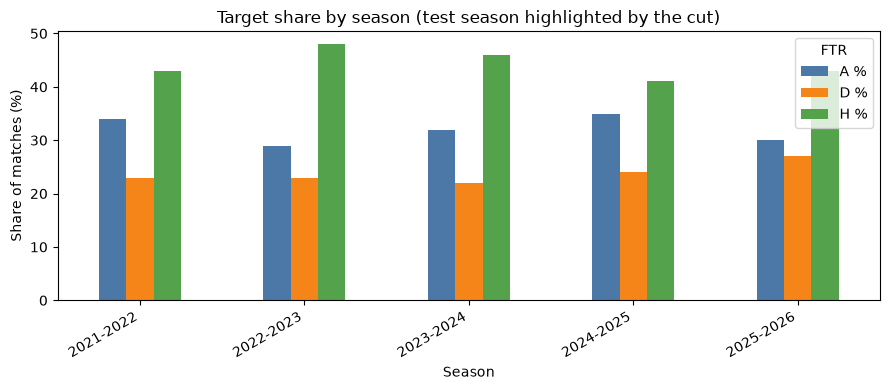

In [25]:

ax = season_share.plot.bar(
    figsize=(9, 4),
    color=["#4C78A8", "#F58518", "#54A24B"],
)
ax.set(
    title="Target share by season (test season highlighted by the cut)",
    xlabel="Season",
    ylabel="Share of matches (%)",
)
ax.legend(title="FTR")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


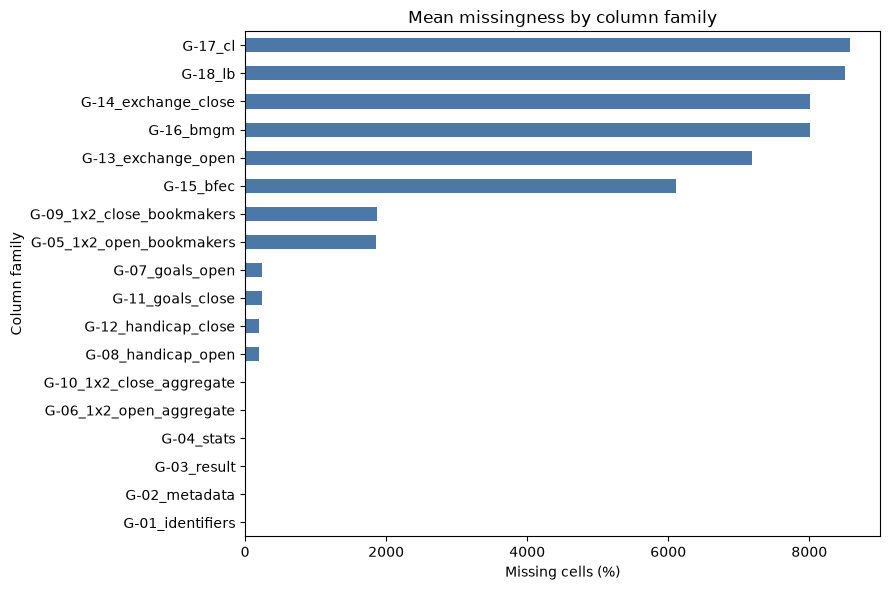

In [26]:
missing_share = (
    100 * inventory.merge(
        df.isna().mean().mul(100).rename("missing_pct"),
        left_on="column",
        right_index=True,
    )
    .groupby("family")["missing_pct"]
    .mean()
    .sort_values()
)

ax = missing_share.plot.barh(figsize=(9, 6), color="#4C78A8")
ax.set(
    title="Mean missingness by column family",
    xlabel="Missing cells (%)",
    ylabel="Column family",
)
plt.tight_layout()
plt.show()


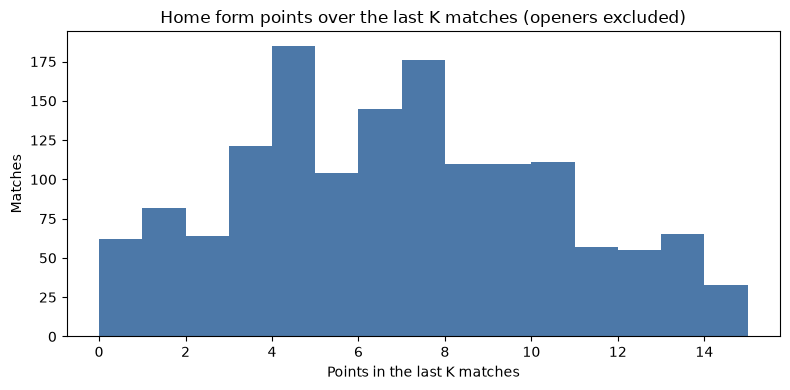

Season openers without history: 40 of 1520 rows


In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(preview["Home_Hist_Pts_k"].dropna(), bins=15, color="#4C78A8")
ax.set(
    title="Home form points over the last K matches (openers excluded)",
    xlabel="Points in the last K matches",
    ylabel="Matches",
)
plt.tight_layout()
plt.show()

openers = int(preview["Home_Hist_Pts_k"].isna().sum())
print(f"Season openers without history: {openers} of {len(preview)} rows")
